# Data provenance and cohort reconstruction

This entry point audits the preserved snapshots and derives in-memory cohorts. It does not overwrite input CSVs. NLP preserves 1,090 rows; quantitative analysis uses 1,035 micro and 1,174 large rows.

See [reproducibility](../docs/REPRODUCIBILITY.md) and [evidence audit](../docs/EVIDENCE_AUDIT.md).

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'scripts/analyze.py').exists():
    ROOT = ROOT.parent
assert (ROOT / 'scripts/analyze.py').exists(), 'Open from repository root or notebooks/'
sys.path.insert(0, str(ROOT / 'scripts'))
import analyze
import pandas as pd
from IPython.display import display, Image


In [2]:
analyze.audit()
analyze.provenance()

## Data audit

In [3]:
display(pd.read_csv(ROOT / 'results/tables/data_audit.csv').head(20))

,dataset,rows,unique_videos,unique_channels,zero_views,zero_subscribers,like_rate_above_one
0,raw_collection,1108,1090,1071,29,26,1
1,micro_snapshot,1090,1090,1053,29,26,1
2,large_snapshot,1177,1177,1146,0,0,0
3,micro_analysis,1035,1035,1001,0,0,0
4,large_analysis,1174,1174,1143,0,0,0


## Cohort flow

In [4]:
display(pd.read_csv(ROOT / 'results/tables/cohort_flow.csv').head(20))

,step,rows
0,Saved micro snapshot,1090
1,Positive views,1061
2,Valid like rate,1060
3,"Positive subscribers below 10,000",1035


## Text coverage

In [5]:
display(pd.read_csv(ROOT / 'results/tables/text_coverage.csv').head(20))

,dataset,field,nonempty,rows,coverage
0,micro_snapshot,description,623,1090,0.571560
1,micro_analysis,description,592,1035,0.571981
2,micro_snapshot,tags,332,1090,0.304587
3,micro_analysis,tags,315,1035,0.304348
4,micro_snapshot,top_comments_text,404,1090,0.370642
5,micro_analysis,top_comments_text,402,1035,0.388406
6,micro_snapshot,hashtags_from_title,755,1090,0.692661
7,micro_analysis,hashtags_from_title,727,1035,0.702415
8,micro_snapshot,hashtags_from_desc,502,1090,0.460550
9,micro_analysis,hashtags_from_desc,477,1035,0.460870


## Reviewed figure

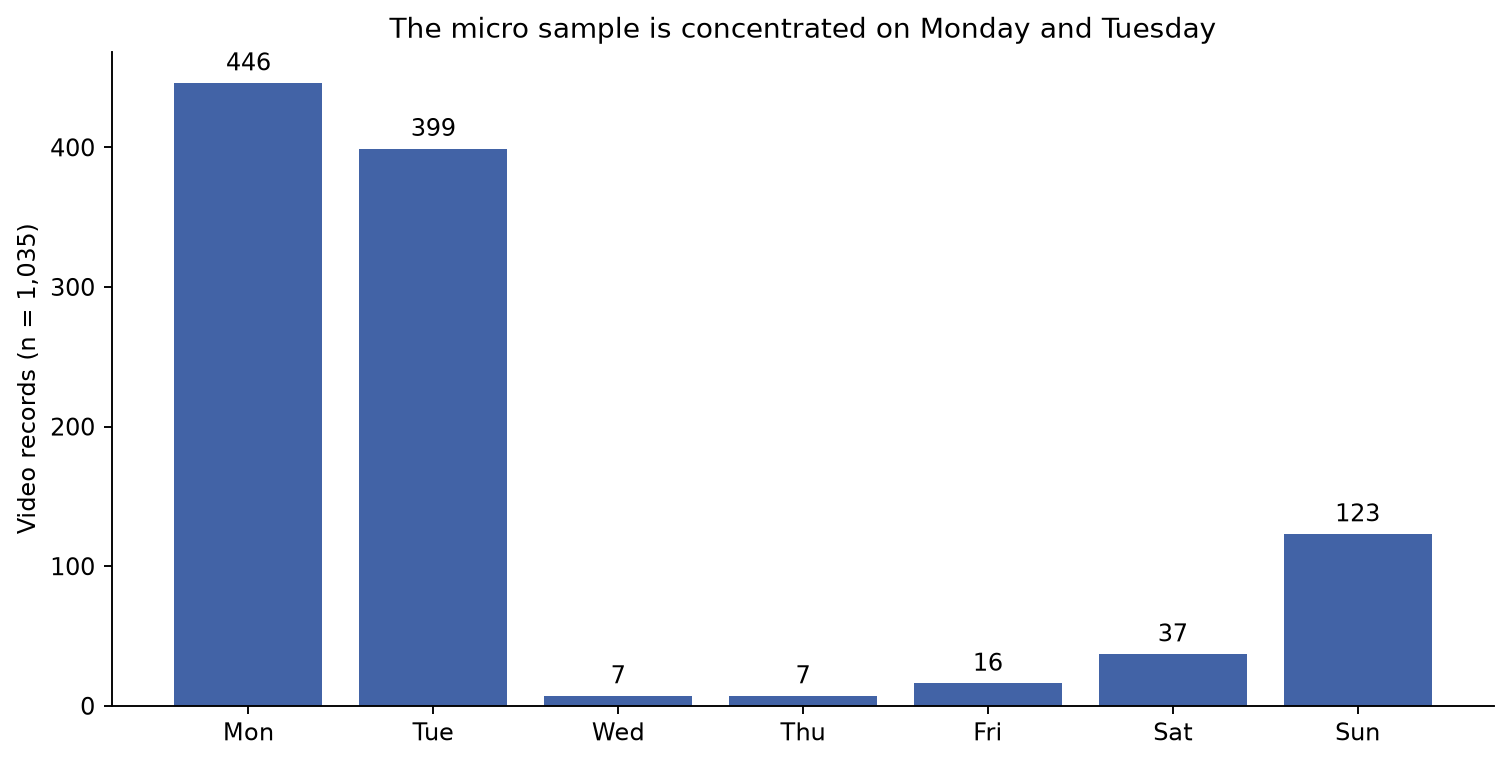

In [6]:
display(Image(filename=str(ROOT / 'results/figures/sampling_by_day.png')))